### This Notebook demonstrate how to generate tf.records from the lsdb file compatible for the model and performs preprocessing.

In [20]:
import os
import tensorflow as tf
from lsdb import read_hats
import matplotlib.pyplot as plt
from dask.distributed import Client
from dart.bands.bands import ztf_band
from dart.src.dataset import create_dataset

In [ ]:
#
# Read catalog
#
read_catalog = read_hats('/media3/majumder/dataset/cepheids/hats/zubercal_vcep', )
path_to_store="/media3/majumder/dataset/cepheids/"
#
#
#
catalog_compute = read_catalog._ddf.map_partitions(create_dataset, 
                                                        target=path_to_store,
                                                        bands=ztf_band,
                                                        seed=42,
                                                        min_detec=100,
                                                        train_size=.80,
                                                        max_lcs_per_chunk=100)

with Client() as client:
    catalog_compute.compute(scheduler='processes')


print("\nDone!")

    

### Generate histogram of the lightcurve for each ZTF-band

In [ ]:
#
#
#
hist = dict()
labels = list()
chunks = list()
filenames = list()
path = f"/media3/majumder/dataset/cepheids/test/"
#
#
#
for p in os.listdir(path):
    for lbl in os.listdir(path+p):
        for cnk in os.listdir(path+p+"/"+lbl):
            filenames.append(path+p+"/"+lbl+'/'+cnk)
# print(filenames)
#
#
#
for k in ztf_band.keys():
    hist[k] = list()

for f in filenames:
    #
    #
    #
    dataset = tf.data.TFRecordDataset(f)
    #
    #
    #
    for rec in dataset:
        #
        example = tf.train.SequenceExample()
        example.ParseFromString(rec.numpy())
        #
        last_index = example.context.feature['last_index'].int64_list.value
        time = example.feature_lists.feature_list['dim_0'].feature[0].float_list.value
        mag = example.feature_lists.feature_list['dim_1'].feature[0].float_list.value
        band_sorted = example.feature_lists.feature_list['dim_3'].feature[0].float_list.value
        last_index = example.context.feature['last_index'].int64_list.value
        id = example.context.feature['id'].int64_list.value[0]
        
        # 
        j=0
        for i, l in enumerate(hist.keys()):
            #
            temp = last_index[i]+1
            length = temp-j
            hist[l].append(length)
            j = temp
            
print(hist)

In [ ]:
l=[]
for i in hist['g']:
    if i == 0:
        l.append(i)
print(l)
print(len(l))
print(len(hist['g']))

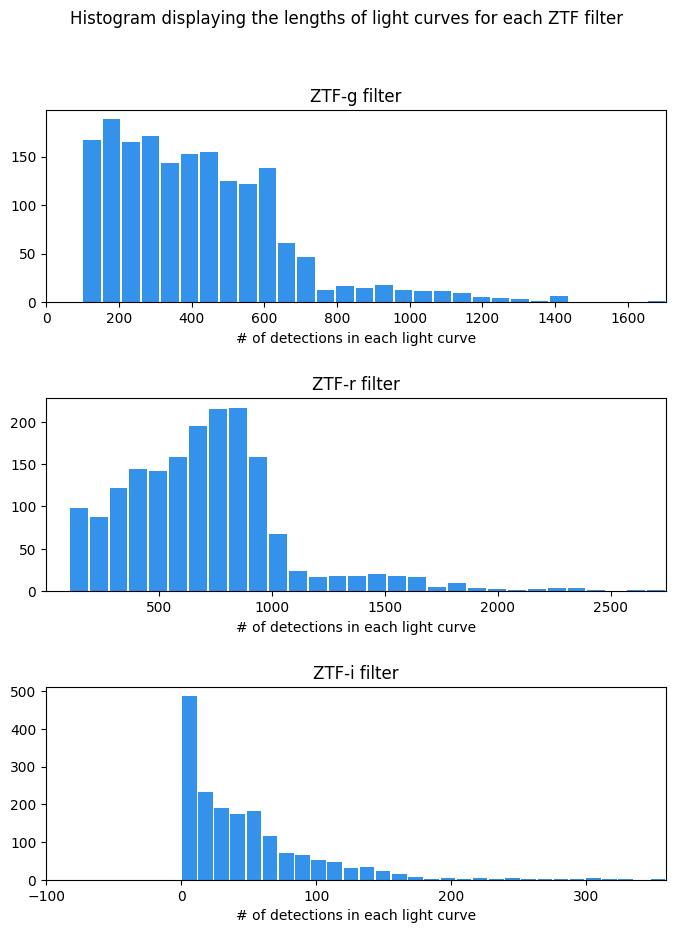

In [21]:
#
#
#
plt.figure(figsize=(8, 10))
plt.suptitle(f"Histogram displaying the lengths of light curves for each ZTF filter")
for i , k in enumerate(hist.keys()):
    # 
    # list_to_array = np.array(hist[k])
    # idx = np.where(list_to_array <= 10)
    plt.subplot(3, 1, i+1)
    plt.hist(hist[k], bins=30, color="#3492eb", rwidth=0.9)
    plt.xlim(min(hist[k])-100, max(hist[k]))
    # print(min(hist[k]), max(hist[k]), len(hist[k]))
    plt.title(f"ZTF-{k} filter")
    plt.subplots_adjust(hspace=0.5)
    plt.xlabel("# of detections in each light curve")
# plt.savefig("./cephids/length.png")